In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

In [ ]:

def count_and_plot_blood_clots(image_path, is_stroke):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if not is_stroke:
        return None

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    _, brain_mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=3)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=2)
    brain_only = cv2.bitwise_and(img, img, mask=brain_mask)

    edges = cv2.Canny(brain_only, threshold1=30, threshold2=100)
    kernel = np.ones((3, 3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(edges_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    clot_count = 0
    min_area = 20
    max_area = 2500
    clot_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    for contour in contours:
        area = cv2.contourArea(contour)
        if min_area < area < max_area:
            x, y, w, h = cv2.boundingRect(contour)
            if np.mean(brain_mask[y:y+h, x:x+w]) > 128:
                clot_count += 1
                cv2.rectangle(clot_img, (x, y), (x + w, y + h), (0, 0, 255), 2)
                cv2.putText(clot_img, "Clot", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Enhanced CT Scan")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(clot_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Clots: {clot_count}")
    plt.axis("off")

    plt.show()
    return clot_count if clot_count > 0 else "No Clots Detected"

def classify_brain_ct(image_path, model):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]
    is_stroke = prediction > 0.5

    clot_result = count_and_plot_blood_clots(image_path, is_stroke) if is_stroke else None
    return "Stroke" if is_stroke else "Normal", clot_result

def test_single_image(image_path, model):
    classification, clot_count = classify_brain_ct(image_path, model)
    print(f"Image: {image_path}\nClassification: {classification}\nClot Count: {clot_count}")

model_path = '/content/drive/MyDrive/brainstroke_model.h5'
model = load_model(model_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


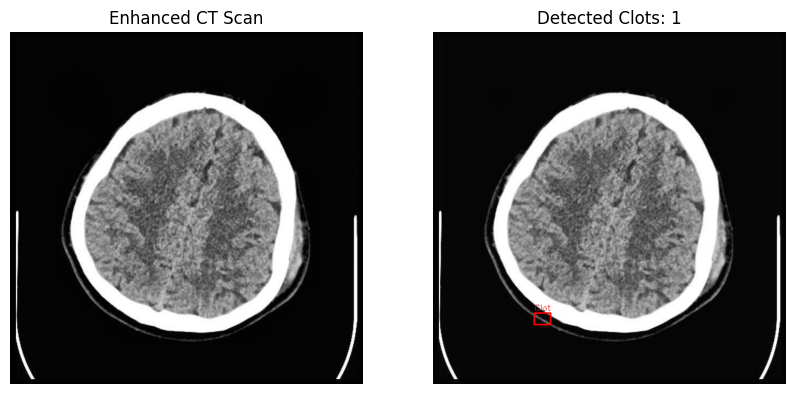

Image: /content/drive/MyDrive/Brain_Data_Organised/Stroke/83 (36).jpg
Classification: Stroke
Clot Count: 1


In [ ]:
# Example Usage
image_path = '/content/drive/MyDrive/Brain_Data_Organised/Stroke/83 (36).jpg'
test_single_image(image_path, model)